In [1]:
from sklearn.model_selection import train_test_split
import os
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
import parselmouth
import pandas as pd
from tensorflow.keras.models import load_model
from sincnet_tensorflow import LayerNorm 
from sklearn.metrics import f1_score
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, LeakyReLU, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import librosa.display
import soundfile as sf  
import librosa

Unificar audios del formulario a misma frecuencia y un solo canal

In [ ]:
def preprocess_and_save_audio(file_path, output_dir):
    try:
        # Cargar el archivo de audio
        sound = parselmouth.Sound(file_path)
        
        # Obtener la tasa de muestreo
        sample_rate = sound.sampling_frequency
        
        # Obtener el número de canales
        num_channels = sound.n_channels
        
        # Convertir el audio a un array de numpy
        audio_array = sound.values
        
        # Verificar el contenido del array de audio
        if audio_array.size == 0:
            print(f"El archivo '{file_path}' está vacío.")
            return
        
        # Si el audio tiene 2 canales, tomar solo el primer canal para simplificar
        if num_channels == 2:
            # Asegurarse de tomar el canal correcto dependiendo de la forma del array
            if audio_array.shape[0] == 2:  # Formato (2, N)
                audio_array = audio_array[0, :]  # Tomar el primer canal (canal izquierdo)
            elif audio_array.shape[1] == 2:  # Formato (N, 2)
                audio_array = audio_array[:, 0]  # Tomar el primer canal (canal izquierdo)
        
        # Crear un nuevo objeto Sound con el array de audio procesado (un canal)
        new_sound = parselmouth.Sound(audio_array, sampling_frequency=sample_rate)
        
        # Guardar el archivo de audio procesado en la carpeta de salida
        output_file_path = os.path.join(output_dir, os.path.basename(file_path))
        new_sound.save(output_file_path, format="WAV")
        
        print(f"Archivo procesado y guardado en: {output_file_path}")
    except Exception as e:
        print(f"Error al procesar el archivo '{file_path}': {e}")

# Ruta de los archivos de audio
audio_dir = 'audios_resampled'
output_dir = 'not_padded'

# Crear la carpeta de salida si no existe
os.makedirs(output_dir, exist_ok=True)

# Preprocesar y guardar todos los audios
for file in os.listdir(audio_dir):
    if file.endswith('.wav'):
        file_path = os.path.join(audio_dir, file)
        preprocess_and_save_audio(file_path, output_dir)



Generador de imágenes STFT a partir de los audios y guardarlas en local 

In [ ]:
# Crear la carpeta "ventanas" si no existe
output_dir = 'audio_frecuencia_not_padded'
os.makedirs(output_dir, exist_ok=True)

# Procesar los archivos de audio
for x in range(23, 26):  # x desde 1 hasta 25
    for y in range(2, 77):  # y desde 2 hasta 76
        file_name = f'not_padded/{x}audio_{y}.wav'  # Ruta del archivo de audio
        if not os.path.exists(file_name):
            continue  # Saltar si el archivo no existe
        
        # Cargar el archivo de audio
        y_audio, sr = librosa.load(file_name)

        # Calcular el espectrograma del audio completo
        D = librosa.amplitude_to_db(np.abs(librosa.stft(y_audio)), ref=np.max)

        # Crear el gráfico del espectrograma en color
        plt.figure(figsize=(12, 8))
        librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', cmap='viridis')  # Usar 'viridis' para colores
        plt.colorbar(format='%+2.0f dB')
        plt.title(f'Espectrograma de amplitud del audio completo')
        plt.xlabel('Tiempo (s)')
        plt.ylabel('Frecuencia (Hz)')
        
        # Guardar el gráfico en la subcarpeta correspondiente
        plt.savefig(os.path.join(output_dir, f'{x}audio_{y}_completo.png'))
        plt.close()  # Cerrar la figura para liberar memoria


Ver dimensión de la imagen generada

Tamaño de la imagen: (576, 864, 4)


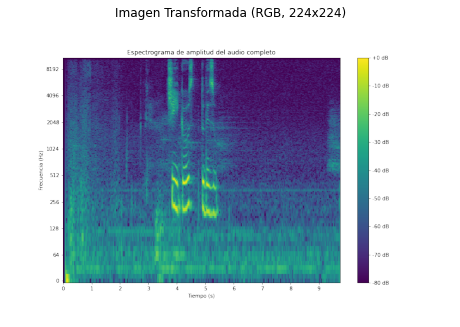

In [12]:
# Cargar la imagen con PIL (como en tu código original)
img = Image.open('C:/Users/mussi/Desktop/TFG/audio_frecuencia_not_padded/1audio_7_completo.png')

# Convertir la imagen a un array numpy
img_array = np.array(img)

# Ver las dimensiones de la imagen
print(f'Tamaño de la imagen: {img_array.shape}')

# Plotear la imagen
plt.figure(figsize=(8, 8))
plt.imshow(img_array)
plt.title("Imagen Transformada (RGB, 224x224)")
plt.axis('off')  # Ocultar los ejes
plt.show()


Transformar para que sea entrada válida para VGG16

Tamaño de la imagen después de procesar: (224, 224, 3)


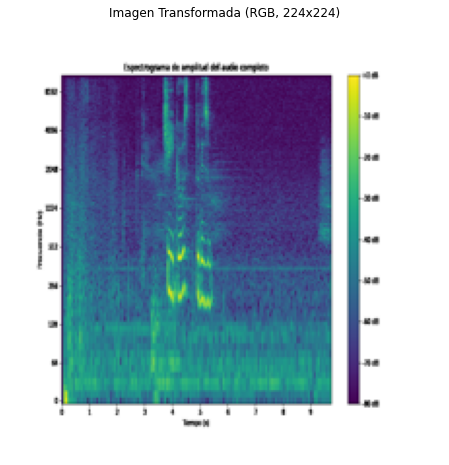

In [13]:
from PIL import Image

# Cargar la imagen
img = Image.open('C:/Users/mussi/Desktop/TFG/audio_frecuencia_not_padded/1audio_7_completo.png')

# Convertir a RGB para eliminar el canal alfa (si existe)
img = img.convert("RGB")

# Redimensionar la imagen a 224x224
img = img.resize((224, 224))

# Convertir la imagen a un array numpy
img_array = np.array(img)

# Verificar las dimensiones
print(f"Tamaño de la imagen después de procesar: {img_array.shape}")

# Plotear la imagen
plt.figure(figsize=(8, 8))
plt.imshow(img_array)
plt.title("Imagen Transformada (RGB, 224x224)")
plt.axis('off')  # Ocultar los ejes
plt.show()



Generar la variable 'X' con las imágenes guardadas en local

In [2]:
def load_images_from_folder(image_folder, input_size=(224, 224)):
    # Lista para almacenar las imágenes cargadas
    X = []

    # Recorrer las posibles combinaciones de x y y
    for x in range(1, 26):  # X va de 1 a 25
        for y in range(2, 77):  # Y va de 2 a 76
            # Crear el nombre del archivo con el formato 'xaudio_y_completo.png'
            image_name = f'{x}audio_{y}_completo.png'
            image_path = os.path.join(image_folder, image_name)

            # Comprobar si el archivo existe
            if os.path.isfile(image_path):
                try:
                    # Cargar la imagen generada del espectrograma
                    img = Image.open(image_path)

                    # Convertir la imagen a RGB (eliminando cualquier canal alfa)
                    img_rgb = img.convert("RGB")

                    # Redimensionar la imagen al tamaño especificado
                    img_resized = img_rgb.resize(input_size)

                    # Convertir la imagen a una matriz numpy
                    img_array_resized = np.array(img_resized)

                    # Agregar la imagen a la lista
                    X.append(img_array_resized)

                except Exception as e:
                    print(f"Error al procesar la imagen {image_name}: {e}")

    # Convertir la lista en un array numpy
    X = np.array(X)

    # Devolver el array de imágenes
    return X

In [3]:
image_folder = 'audio_frecuencia_not_padded'
X = load_images_from_folder(image_folder)

# Verificar la forma final de las imágenes cargadas
print(f"Imágenes cargadas en la variable X con forma: {X.shape}")


Imágenes cargadas en la variable X con forma: (1870, 224, 224, 3)


Visualizar un valor de X

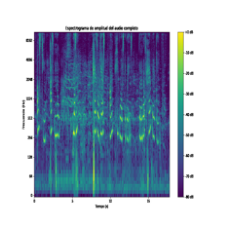

In [ ]:
# Asegurarse de que hay imágenes en X
if len(X) > 0:
    # Tomar la primera imagen
    image = X[1667]

    # Quitar la dimensión extra para mostrar la imagen en escala de grises
    plt.imshow(image.squeeze(), cmap='gray')

    # Título y ajustes del gráfico
    plt.axis('off')  # Ocultar los ejes

    # Mostrar la imagen
    plt.show()
else:
    print("La variable X está vacía.")


Generar variable 'y' a partir del etiquetamiento de datos en el csv.

In [4]:
import pandas as pd

def load_and_select_columns(csv_file, start_col=1, end_col=10):
    # Cargar el archivo CSV
    data = pd.read_csv(csv_file)

    # Seleccionar las columnas desde la 'start_col' hasta la 'end_col' (no inclusive)
    y = data.iloc[:, start_col:end_col]

    # Devolver la variable seleccionada
    return y


In [5]:
csv_file = 'data.csv'
y = load_and_select_columns(csv_file)

# Verificar el resultado
print(f"Forma de la variable y: {y.shape}")
print(y.head())  # Mostrar las primeras filas de y


Forma de la variable y: (1870, 9)
   1  2  3  4  5  6  7  8  9
0  0  0  0  1  0  0  0  0  0
1  0  1  0  1  0  0  0  0  0
2  0  0  0  1  0  0  0  0  0
3  0  0  1  1  0  0  0  0  0
4  1  0  1  1  0  0  0  1  0


Generar datos de train y validación

In [6]:
# Divide los datos en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1496, 224, 224, 3), (374, 224, 224, 3), (1496, 9), (374, 9))

Arquitectura de modelo con Conv2D

In [8]:
def create_model(input_shape=(224, 224, 3), out_dim=9):
    # Definir las entradas con forma (224, 224, 3)
    inputs = Input(input_shape)

    # Primera capa Conv2D
    x = Conv2D(32, (3, 3), strides=1, padding='valid')(inputs)
    x = LeakyReLU(alpha=0.2)(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Segunda capa Conv2D
    x = Conv2D(64, (3, 3), strides=1, padding='valid')(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Tercera capa Conv2D
    x = Conv2D(128, (3, 3), strides=1, padding='valid')(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Aplanado
    x = Flatten()(x)
    x = Dropout(0.3)(x)

    # Primera capa densa
    x = Dense(256)(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.5)(x)

    # Segunda capa densa
    x = Dense(256)(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.5)(x)

    # Capa de salida
    prediction = Dense(out_dim, activation='sigmoid')(x)

    # Crear el modelo
    model = tf.keras.models.Model(inputs=inputs, outputs=prediction)

    return model

In [9]:
model = create_model(input_shape=(224, 224, 3), out_dim=9)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 222, 222, 32)      0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 109, 109, 64)      0         
                                                             

In [11]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True) #parar si val_loss no mejora en 3 epochs
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
conv2D_modelo = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping]) 

Epoch 1/10
47/47 [==============================] - 91s 2s/step - loss: 14.8293 - binary_accuracy: 0.6735 - val_loss: 2.3049 - val_binary_accuracy: 0.7546
Epoch 2/10
47/47 [==============================] - 93s 2s/step - loss: 2.1584 - binary_accuracy: 0.7285 - val_loss: 0.5298 - val_binary_accuracy: 0.7926
Epoch 3/10
47/47 [==============================] - 90s 2s/step - loss: 0.9060 - binary_accuracy: 0.7521 - val_loss: 0.4454 - val_binary_accuracy: 0.7864
Epoch 4/10
47/47 [==============================] - 107s 2s/step - loss: 0.7807 - binary_accuracy: 0.7576 - val_loss: 0.4671 - val_binary_accuracy: 0.7739
Epoch 5/10
47/47 [==============================] - 93s 2s/step - loss: 1.0268 - binary_accuracy: 0.7582 - val_loss: 0.4805 - val_binary_accuracy: 0.7867
Epoch 6/10
47/47 [==============================] - 87s 2s/step - loss: 0.5733 - binary_accuracy: 0.7908 - val_loss: 0.3817 - val_binary_accuracy: 0.7941
Epoch 7/10
47/47 [==============================] - 92s 2s/step - loss: 0.

Guardar el modelo en h5

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Crear el callback para EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True) 

# Crear el callback para guardar el modelo
model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss', mode='min', verbose=1)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])

# Entrenar el modelo con EarlyStopping y ModelCheckpoint
conv2D_modelo = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val),
                           callbacks=[early_stopping, model_checkpoint])


Epoch 1/10
47/47 [==============================] - ETA: 0s - loss: 14.9080 - binary_accuracy: 0.6419
Epoch 1: val_loss improved from inf to 0.99050, saving model to best_model.h5


C:\Users\mussi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


47/47 [==============================] - 72s 1s/step - loss: 14.9080 - binary_accuracy: 0.6419 - val_loss: 0.9905 - val_binary_accuracy: 0.7677
Epoch 2/10
47/47 [==============================] - ETA: 0s - loss: 1.6481 - binary_accuracy: 0.6995
Epoch 2: val_loss improved from 0.99050 to 0.42020, saving model to best_model.h5
47/47 [==============================] - 75s 2s/step - loss: 1.6481 - binary_accuracy: 0.6995 - val_loss: 0.4202 - val_binary_accuracy: 0.7763
Epoch 3/10
47/47 [==============================] - ETA: 0s - loss: 0.6837 - binary_accuracy: 0.7461
Epoch 3: val_loss improved from 0.42020 to 0.38933, saving model to best_model.h5
47/47 [==============================] - 71s 2s/step - loss: 0.6837 - binary_accuracy: 0.7461 - val_loss: 0.3893 - val_binary_accuracy: 0.8015
Epoch 4/10
47/47 [==============================] - ETA: 0s - loss: 0.5809 - binary_accuracy: 0.7686
Epoch 4: val_loss did not improve from 0.38933
47/47 [==============================] - 71s 2s/step - l

In [11]:
# Visualizar el historial
def plot_history(history):
    # Pérdida
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
    plt.plot(history.history['val_loss'], label='Pérdida de validación')
    plt.title('Pérdida durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()

    # Precisión
    plt.subplot(1, 2, 2)
    plt.plot(history.history['binary_accuracy'], label='Precisión de entrenamiento')
    plt.plot(history.history['val_binary_accuracy'], label='Precisión de validación')
    plt.title('Precisión durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()

    plt.tight_layout()
    plt.show()

Plot del modelo que no fue guardado en h5

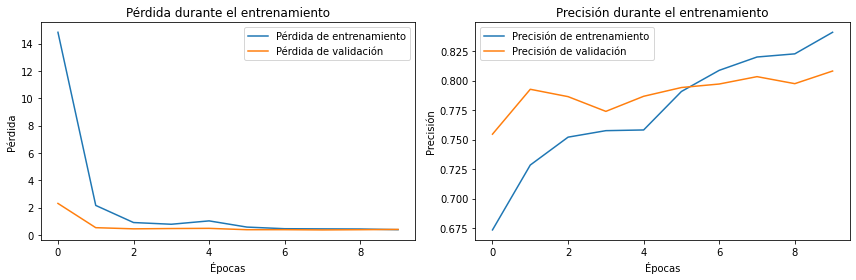

In [13]:
# Llamar a la función para trazar el historial
plot_history(conv2D_modelo)

Arquitectura usando vgg16 (se crea nuevo modelo que cargue vgg16)

In [17]:
# Dimensiones de salida
out_dim = 9

# Cargar el modelo VGG16 preentrenado, quitando la parte superior (include_top=False)
# Ajustamos input_shape para aceptar imágenes de tamaño (150, 150, 3)
vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congelar las capas del modelo preentrenado para que no se actualicen durante el entrenamiento
vgg.trainable = False

# Crear la entrada del modelo con forma (150, 150, 1), repitiendo el canal 1 tres veces
inputs = Input((224, 224, 3))

# Pasar las entradas por el modelo VGG16
x = vgg(inputs)

# Aplanar la salida
x = Flatten()(x)

# Añadir capas densas
x = Dense(128)(x)
x = LeakyReLU(alpha=0.2)(x)
x = Dropout(0.5)(x)

x = Dense(128)(x)
x = LeakyReLU(alpha=0.2)(x)
x = Dropout(0.5)(x)

# Capa de salida con 'sigmoid' para clasificar 9 etiquetas binarias
prediction = Dense(out_dim, activation='sigmoid')(x)

# Crear el modelo completo
model = Model(inputs=inputs, outputs=prediction)

# Mostrar el resumen del modelo
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten_2 (Flatten)         (None, 25088)             0         
                                                                 
 dense_6 (Dense)             (None, 128)               3211392   
                                                                 
 leaky_re_lu_10 (LeakyReLU)  (None, 128)               0         
                                                                 
 dropout_6 (Dropout)         (None, 128)               0         
                                                                 
 dense_7 (Dense)             (None, 128)               1651

In [18]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True) #parar si val_loss no mejora en 2 epochs
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
VGG16_modelo = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping]) 

Epoch 1/10
47/47 [==============================] - 278s 6s/step - loss: 6.0173 - binary_accuracy: 0.6680 - val_loss: 1.1133 - val_binary_accuracy: 0.7882
Epoch 2/10
47/47 [==============================] - 323s 7s/step - loss: 2.3941 - binary_accuracy: 0.7299 - val_loss: 0.7989 - val_binary_accuracy: 0.7923
Epoch 3/10
47/47 [==============================] - 319s 7s/step - loss: 1.8329 - binary_accuracy: 0.7419 - val_loss: 0.6368 - val_binary_accuracy: 0.7807
Epoch 4/10
47/47 [==============================] - 323s 7s/step - loss: 1.4697 - binary_accuracy: 0.7620 - val_loss: 0.5421 - val_binary_accuracy: 0.7843
Epoch 5/10
47/47 [==============================] - 317s 7s/step - loss: 1.3719 - binary_accuracy: 0.7560 - val_loss: 0.5156 - val_binary_accuracy: 0.7935
Epoch 6/10
47/47 [==============================] - 323s 7s/step - loss: 1.2415 - binary_accuracy: 0.7700 - val_loss: 0.4985 - val_binary_accuracy: 0.8078
Epoch 7/10
47/47 [==============================] - 321s 7s/step - los

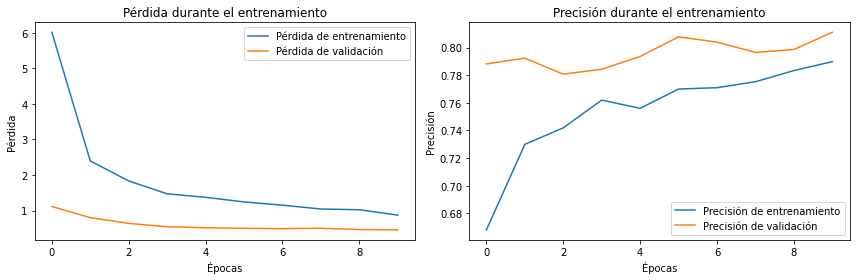

In [19]:
plot_history(VGG16_modelo)

# Imágenes con padding

Importar X

In [6]:
image_folder = 'audios_frecuencia'
X = load_images_from_folder(image_folder)

# Verificar la forma final de las imágenes cargadas
print(f"Imágenes cargadas en la variable X con forma: {X.shape}")

Imágenes cargadas en la variable X con forma: (1870, 224, 224, 3)


In [7]:
csv_file = 'data.csv'
y = load_and_select_columns(csv_file)

# Verificar el resultado
print(f"Forma de la variable y: {y.shape}")
print(y.head())  # Mostrar las primeras filas de y


Forma de la variable y: (1870, 9)
   1  2  3  4  5  6  7  8  9
0  0  0  0  1  0  0  0  0  0
1  0  1  0  1  0  0  0  0  0
2  0  0  0  1  0  0  0  0  0
3  0  0  1  1  0  0  0  0  0
4  1  0  1  1  0  0  0  1  0


In [8]:
# Divide los datos en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1496, 224, 224, 3), (374, 224, 224, 3), (1496, 9), (374, 9))

Mismo modelo que al inicio pero con nuevo dataset

In [14]:
model = create_model(input_shape=(224, 224, 3), out_dim=9)

# Mostrar el resumen del modelo
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d_3 (Conv2D)           (None, 224, 224, 32)      896       
                                                                 
 leaky_re_lu_5 (LeakyReLU)   (None, 224, 224, 32)      0         
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 112, 112, 32)      0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 leaky_re_lu_6 (LeakyReLU)   (None, 112, 112, 64)      0         
                                                           

In [19]:
early_stopping = EarlyStopping(monitor='val_binary_accuracy', patience=3, restore_best_weights=True) #parar si val_loss no mejora en 2 epochs
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
conv_modelo = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping]) 

Epoch 1/10
47/47 [==============================] - 87s 2s/step - loss: 37.5917 - binary_accuracy: 0.6648 - val_loss: 6.1169 - val_binary_accuracy: 0.7395
Epoch 2/10
47/47 [==============================] - 89s 2s/step - loss: 10.6935 - binary_accuracy: 0.7091 - val_loss: 1.9448 - val_binary_accuracy: 0.7766
Epoch 3/10
47/47 [==============================] - 81s 2s/step - loss: 6.6672 - binary_accuracy: 0.7190 - val_loss: 1.6926 - val_binary_accuracy: 0.7745
Epoch 4/10
47/47 [==============================] - 78s 2s/step - loss: 3.9878 - binary_accuracy: 0.7275 - val_loss: 1.0724 - val_binary_accuracy: 0.7965
Epoch 5/10
47/47 [==============================] - 83s 2s/step - loss: 3.3792 - binary_accuracy: 0.7392 - val_loss: 1.0661 - val_binary_accuracy: 0.7852
Epoch 6/10
47/47 [==============================] - 90s 2s/step - loss: 2.5963 - binary_accuracy: 0.7457 - val_loss: 0.9711 - val_binary_accuracy: 0.7947
Epoch 7/10
47/47 [==============================] - 91s 2s/step - loss: 2.

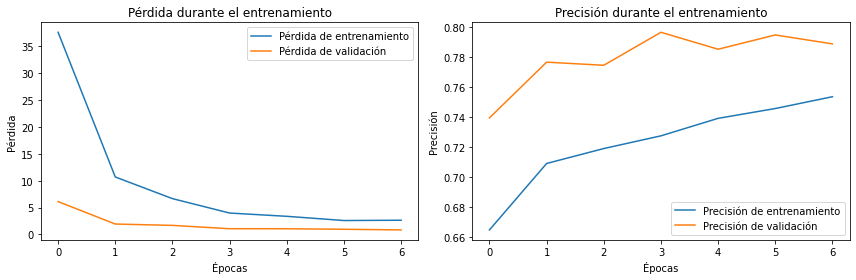

In [22]:
plot_history(conv_modelo)